In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from cmocean import cm as cmo
import matplotlib.dates as mdates
import numpy as np
import scipy as sc
import pandas as pd
import xarray as xr
import sys
import gzip
import glob
import re
import pickle
from scipy.interpolate import griddata
from scipy.interpolate import griddata
from skspatial.objects import Line
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import piecewise_regression


sys.path.append("C:\\Users\\vrmio\\Documents\\Andrea\\code\\scripts")
import utils_glider_data as ut

mpl.rcParams['agg.path.chunksize'] = 10000
plt.rcParams.update({'font.size': 12})

# choose colours
uc = "#298c8c"
cc = "#800074"

In [2]:
# load smoothed profiles and flash density profiles

smooth = xr.open_mfdataset("..\\data\\smooth_profiles.nc")
FD = xr.open_mfdataset("..\\data\\flash_density_profiles.nc")

In [4]:
# where either ubat or biosealight is NaN, make both NaN for consistency

ubat_tmp = smooth.ubat_smooth.values.flatten()
cem_tmp = smooth.cem_smooth.values.flatten()

mask = np.isnan(ubat_tmp) | np.isnan(cem_tmp)
ubat_tmp[mask] = np.nan
cem_tmp[mask] = np.nan

ubat_tmp = ubat_tmp.reshape(np.shape(smooth.ubat_smooth.values))
cem_tmp = cem_tmp.reshape(np.shape(smooth.cem_smooth.values))

smooth['ubat_smooth'] = (['dive_num', 'depth'], ubat_tmp)
smooth['cem_smooth'] = (['dive_num', 'depth'], cem_tmp)

# repeat for flash density
ubat_tmp = FD.ubat.values.flatten()
cem_tmp = FD.cem.values.flatten()

mask = np.isnan(ubat_tmp) | np.isnan(cem_tmp)
ubat_tmp[mask] = np.nan
cem_tmp[mask] = np.nan

ubat_tmp = ubat_tmp.reshape(np.shape(FD.ubat.values))
cem_tmp = cem_tmp.reshape(np.shape(FD.cem.values))

FD['ubat'] = (['dive_num', 'depth'], ubat_tmp)
FD['cem'] = (['dive_num', 'depth'], cem_tmp)



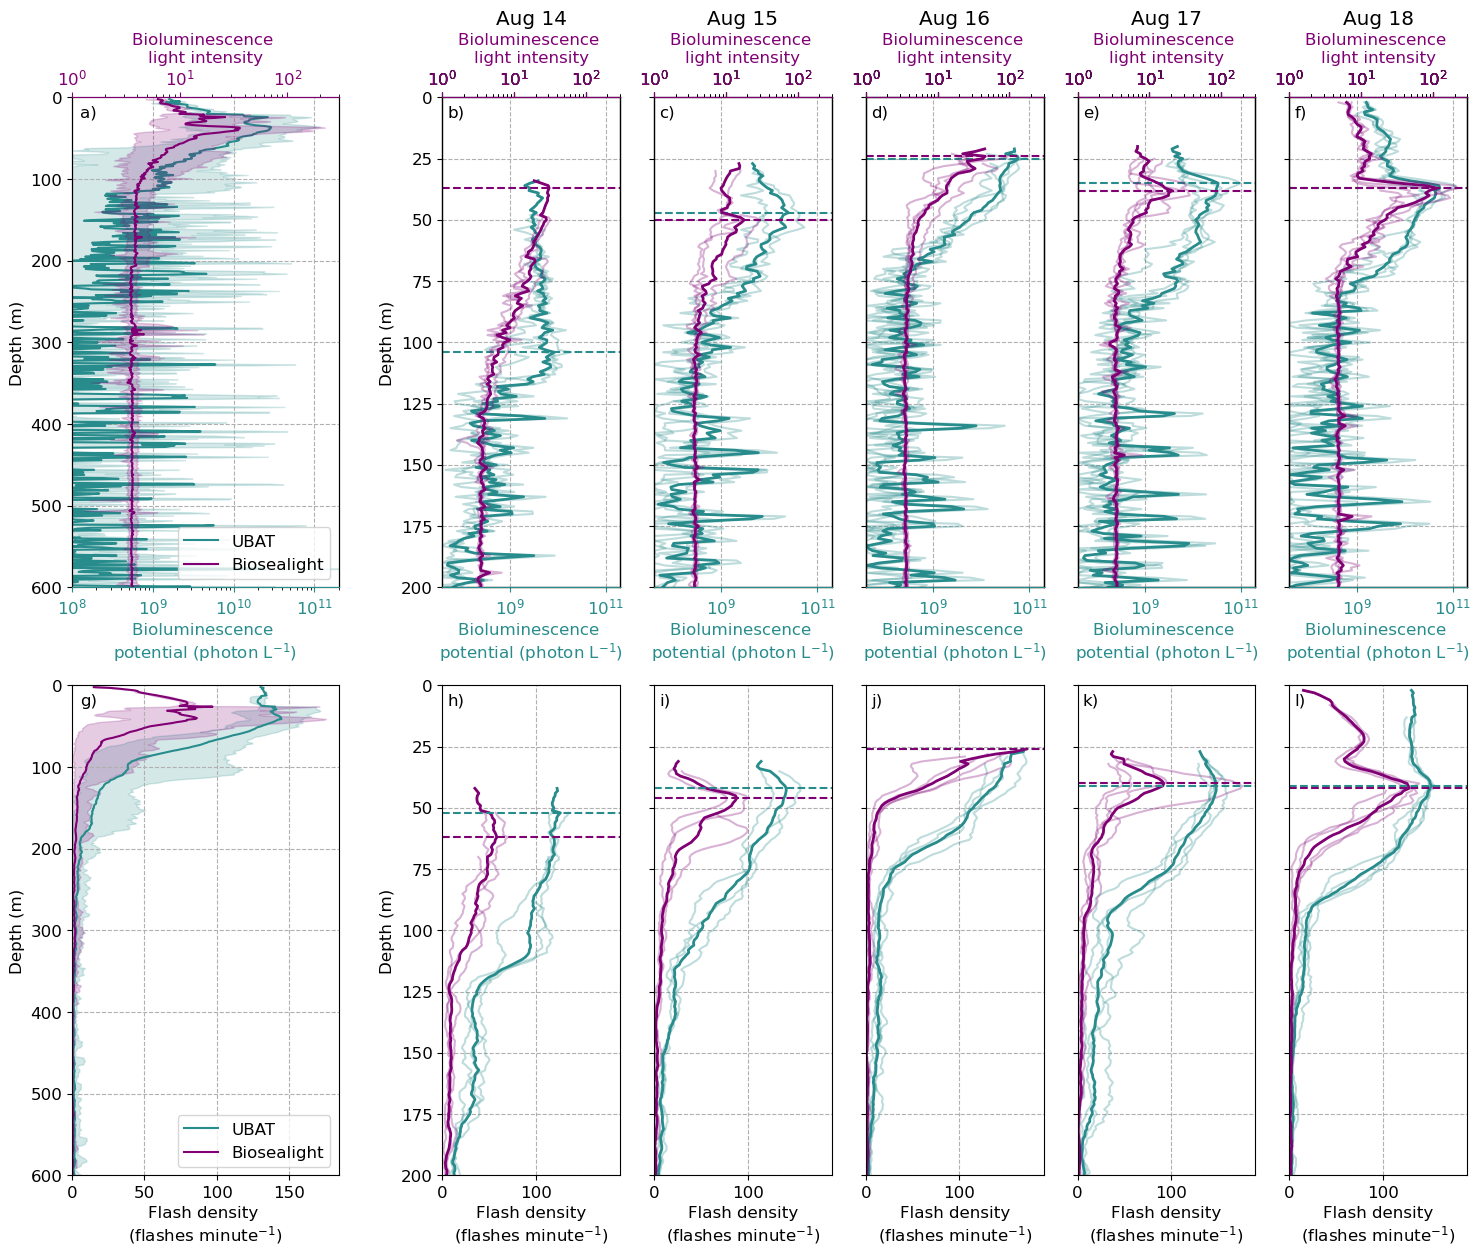

In [5]:
# plot profiles

fig, ax = plt.subplots(2,7, figsize=(18,14), width_ratios=[1.5,0.2,1,1,1,1,1])

####################################################
# FORMAT SPACE

for i in range(2):
    ax[i,1].set_yticklabels([])
    ax[i,1].set_xticklabels([])
    ax[i,1].set_yticks([])
    ax[i,1].set_xticks([])
    ax[i,1].spines['left'].set_color('white')
    ax[i,1].spines['right'].set_color('white')
    ax[i,1].spines['top'].set_color('white')
    ax[i,1].spines['bottom'].set_color('white')
    
####################################################
# NIGHTLY PROFILES SMOOTH

data = smooth

for i in range(0,3):
    ax[0,2].plot(data.ubat_smooth[i], data.depth, c=uc, alpha=0.3)
    axes = [ax[0,2], ax[0,2].twiny()]
    axes[1].plot(data.cem_smooth[i], data.depth, c=cc, alpha=0.3)
    # axes[1].set_xlim(2.8,100)
    axes[1].set_xlim(1,3e2)
    axes[1].set_xscale('log')
ax[0,2].plot(data.ubat_smooth[0:3].mean(axis=0), data.depth, c=uc, lw=2, label='UBAT')
axes[1].plot(data.cem_smooth[0:3].mean(axis=0), data.depth, c=cc, lw=2, label='Biosealight')
ax[0,2].plot(data.cem_smooth[0:3].mean(axis=0), data.depth, c=cc, lw=2, label='Biosealight')
ax[0,2].axhline(data.depth[np.nanargmax(data.ubat_smooth[:3].mean(axis=0))].values, c=uc, ls='--')
ax[0,2].axhline(data.depth[np.nanargmax(data.cem_smooth[:3].mean(axis=0))].values, c=cc, ls='--')
axes[1].set_xlabel('Bioluminescence \nlight intensity', color=cc)
axes[1].spines['bottom'].set_color(uc)
axes[1].spines['top'].set_color(cc)
axes[1].tick_params(axis='x', colors=cc)


for i in range(3,6):
    ax[0,3].plot(data.ubat_smooth[i], data.depth, c=uc, alpha=0.3)
    axes = [ax[0,3], ax[0,3].twiny()]
    axes[1].plot(data.cem_smooth[i], data.depth, c=cc, alpha=0.3)
    # axes[1].set_xlim(2.8,100)
    axes[1].set_xlim(1,3e2)
    axes[1].set_xscale('log')
ax[0,3].plot(data.ubat_smooth[3:6].mean(axis=0), data.depth, c=uc, lw=2)
axes[1].plot(data.cem_smooth[3:6].mean(axis=0), data.depth, c=cc, lw=2)
ax[0,3].axhline(data.depth[np.nanargmax(data.ubat_smooth[3:6,:200].mean(axis=0))].values, c=uc, ls='--')
ax[0,3].axhline(data.depth[np.nanargmax(data.cem_smooth[3:6].mean(axis=0))].values, c=cc, ls='--')
axes[1].set_xlabel('Bioluminescence \nlight intensity', color=cc)
axes[1].spines['bottom'].set_color(uc)
axes[1].spines['top'].set_color(cc)
axes[1].tick_params(axis='x', colors=cc)


for i in range(6,10):
    ax[0,4].plot(data.ubat_smooth[i], data.depth, c=uc, alpha=0.3)
    axes = [ax[0,4], ax[0,4].twiny()]
    axes[1].plot(data.cem_smooth[i], data.depth, c=cc, alpha=0.3)
    # axes[1].set_xlim(2.8,100)
    axes[1].set_xlim(1,3e2)
    axes[1].set_xscale('log')
ax[0,4].plot(data.ubat_smooth[6:10].mean(axis=0), data.depth, c=uc, lw=2)
axes[1].plot(data.cem_smooth[6:10].mean(axis=0), data.depth, c=cc, lw=2)
ax[0,4].axhline(data.depth[np.nanargmax(data.ubat_smooth[6:10].mean(axis=0))].values, c=uc, ls='--')
ax[0,4].axhline(data.depth[np.nanargmax(data.cem_smooth[6:10].mean(axis=0))].values, c=cc, ls='--')
axes[1].set_xlabel('Bioluminescence \nlight intensity', color=cc)
axes[1].spines['bottom'].set_color(uc)
axes[1].spines['top'].set_color(cc)
axes[1].tick_params(axis='x', colors=cc)


for i in range(10,14):
    ax[0,5].plot(data.ubat_smooth[i], data.depth, c=uc, alpha=0.3)
    axes = [ax[0,5], ax[0,5].twiny()]
    axes[1].plot(data.cem_smooth[i], data.depth, c=cc, alpha=0.3)
    # axes[1].set_xlim(2.8,100)
    axes[1].set_xlim(1,3e2)
    axes[1].set_xscale('log')
ax[0,5].plot(data.ubat_smooth[10:14].mean(axis=0), data.depth, c=uc, lw=2)
axes[1].plot(data.cem_smooth[10:14].mean(axis=0), data.depth, c=cc, lw=2) 
ax[0,5].axhline(data.depth[np.nanargmax(data.ubat_smooth[10:14].mean(axis=0))].values, c=uc, ls='--')
ax[0,5].axhline(data.depth[np.nanargmax(data.cem_smooth[10:14].mean(axis=0))].values, c=cc, ls='--')
axes[1].set_xlabel('Bioluminescence \nlight intensity', color=cc)
axes[1].spines['bottom'].set_color(uc)
axes[1].spines['top'].set_color(cc)
axes[1].tick_params(axis='x', colors=cc)


for i in range(14,18):
    ax[0,6].plot(data.ubat_smooth[i], data.depth, c=uc, alpha=0.3)
    axes = [ax[0,6], ax[0,6].twiny()]
    axes[1].plot(data.cem_smooth[i], data.depth, c=cc, alpha=0.3)
    # axes[1].set_xlim(2.8,100)
    axes[1].set_xlim(1,3e2)
    axes[1].set_xscale('log')
ax[0,6].plot(data.ubat_smooth[14:].mean(axis=0), data.depth, c=uc, lw=2)
axes[1].plot(data.cem_smooth[14:].mean(axis=0), data.depth, c=cc, lw=2)  
ax[0,6].axhline(data.depth[np.nanargmax(data.ubat_smooth[14:].mean(axis=0))].values, c=uc, ls='--')
ax[0,6].axhline(data.depth[np.nanargmax(data.cem_smooth[14:].mean(axis=0))].values, c=cc, ls='--')
axes[1].set_xlabel('Bioluminescence \nlight intensity', color=cc)
axes[1].spines['bottom'].set_color(uc)
axes[1].spines['top'].set_color(cc)
axes[1].tick_params(axis='x', colors=cc)

for i in range(2,7): 
    ax[0,i].set_ylim(200,0)
    ax[0,i].grid(ls='--')
    ax[0,i].set_xscale('log')
    ax[0,i].set_xlim(4e7,2e11)    
    ax[0,i].set_xlabel('Bioluminescence \npotential (photon L$^{-1}$)', color=uc)
    ax[0,i].tick_params(axis='x', colors=uc)

for i in range(3,7): 
    ax[0,i].set_yticklabels([])

ax[0,2].set_ylabel('Depth (m)')
ax[0,2].set_title('Aug 14')
ax[0,3].set_title('Aug 15')
ax[0,4].set_title('Aug 16')
ax[0,5].set_title('Aug 17')
ax[0,6].set_title('Aug 18')
# ax[0,2].legend()

########################################################
# FLASH DENSITY PROFILES

data = FD

for i in range(0,3):
    ax[1,2].plot(data.ubat[i], data.depth, c=uc, alpha=0.3)
    ax[1,2].plot(data.cem[i], data.depth, c=cc, alpha=0.3)
ax[1,2].plot(data.ubat[0:3].mean(axis=0), data.depth, c=uc, lw=2, label='UBAT')
ax[1,2].plot(data.cem[0:3].mean(axis=0), data.depth, c=cc, lw=2, label='Biosealight')
ax[1,2].axhline(data.depth[np.nanargmax(data.ubat[:3].mean(axis=0))].values, c=uc, ls='--')
ax[1,2].axhline(data.depth[np.nanargmax(data.cem[:3].mean(axis=0))].values, c=cc, ls='--')

for i in range(3,6):
    ax[1,3].plot(data.ubat[i], data.depth, c=uc, alpha=0.3)
    ax[1,3].plot(data.cem[i], data.depth, c=cc, alpha=0.3)
ax[1,3].plot(data.ubat[3:6].mean(axis=0), data.depth, c=uc, lw=2, label='UBAT')
ax[1,3].plot(data.cem[3:6].mean(axis=0), data.depth, c=cc, lw=2, label='Biosealight')
ax[1,3].axhline(data.depth[np.nanargmax(data.ubat[3:6].mean(axis=0))].values, c=uc, ls='--')
ax[1,3].axhline(data.depth[np.nanargmax(data.cem[3:6].mean(axis=0))].values, c=cc, ls='--')

for i in range(6,10):
    ax[1,4].plot(data.ubat[i], data.depth, c=uc, alpha=0.3)
    ax[1,4].plot(data.cem[i], data.depth, c=cc, alpha=0.3)
ax[1,4].plot(data.ubat[6:10].mean(axis=0), data.depth, c=uc, lw=2, label='UBAT')
ax[1,4].plot(data.cem[6:10].mean(axis=0), data.depth, c=cc, lw=2, label='Biosealight')
ax[1,4].axhline(data.depth[np.nanargmax(data.ubat[6:10].mean(axis=0))].values, c=uc, ls='--')
ax[1,4].axhline(data.depth[np.nanargmax(data.cem[6:10].mean(axis=0))].values, c=cc, ls='--')

for i in range(10,14):
    ax[1,5].plot(data.ubat[i], data.depth, c=uc, alpha=0.3)
    ax[1,5].plot(data.cem[i], data.depth, c=cc, alpha=0.3)
ax[1,5].plot(data.ubat[10:14].mean(axis=0), data.depth, c=uc, lw=2, label='UBAT')
ax[1,5].plot(data.cem[10:14].mean(axis=0), data.depth, c=cc, lw=2, label='Biosealight')
ax[1,5].axhline(data.depth[np.nanargmax(data.ubat[10:14].mean(axis=0))].values, c=uc, ls='--')
ax[1,5].axhline(data.depth[np.nanargmax(data.cem[10:14].mean(axis=0))].values, c=cc, ls='--')

for i in range(14,18):
    ax[1,6].plot(data.ubat[i], data.depth, c=uc, alpha=0.3)
    ax[1,6].plot(data.cem[i], data.depth, c=cc, alpha=0.3)
ax[1,6].plot(data.ubat[14:].mean(axis=0), data.depth, c=uc, lw=2, label='UBAT')
ax[1,6].plot(data.cem[14:].mean(axis=0), data.depth, c=cc, lw=2, label='Biosealight')
ax[1,6].axhline(data.depth[np.nanargmax(data.ubat[14:].mean(axis=0))].values, c=uc, ls='--')
ax[1,6].axhline(data.depth[np.nanargmax(data.cem[14:].mean(axis=0))].values, c=cc, ls='--')


for i in range(2,7): 
    ax[1,i].set_ylim(200,0)
    ax[1,i].grid(ls='--')  
    ax[1,i].set_xlim(0,190)
    ax[1,i].set_xlabel('Flash density\n(flashes minute$^{-1}$)')

for i in range(3,7): 
    ax[1,i].set_yticklabels([])

ax[1,2].set_ylabel('Depth (m)')
# ax[1,2].legend()

#############################################################
# MEAN PROFILES

ax[0,0].plot(smooth.ubat_smooth.mean(axis=0), smooth.depth, c=uc, label='UBAT')
ax[0,0].plot(FD.cem.mean(axis=0), FD.depth, c=cc, label='Biosealight')
ax[0,0].fill_betweenx(smooth.depth, smooth.ubat_smooth.min(axis=0), smooth.ubat_smooth.max(axis=0), color=uc, alpha=0.2)
ax[0,0].set_xscale('log')
ax[0,0].set_ylim(600,0)
ax[0,0].set_xlim(1e8,2e11)

axes = [ax[0,0], ax[0,0].twiny()]
axes[1].plot(smooth.cem_smooth.mean(axis=0), smooth.depth, c=cc, label='Biosealight')
axes[1].fill_betweenx(smooth.depth, smooth.cem_smooth.min(axis=0), smooth.cem_smooth.max(axis=0), color=cc, alpha=0.2)
axes[1].set_xscale('log')
axes[1].set_xlim(1,3e2)


ax[1,0].plot(FD.ubat.mean(axis=0), FD.depth, c=uc, label='UBAT')
ax[1,0].fill_betweenx(FD.depth, FD.ubat.min(axis=0), FD.ubat.max(axis=0), color=uc, alpha=0.2)
ax[1,0].plot(FD.cem.mean(axis=0), FD.depth, c=cc, label='Biosealight')
ax[1,0].fill_betweenx(FD.depth, FD.cem.min(axis=0), FD.cem.max(axis=0), color=cc, alpha=0.2)
ax[1,0].set_ylim(600,0)
ax[1,0].set_xlim(0,None)


ax[0,0].set_ylabel('Depth (m)')
ax[1,0].set_ylabel('Depth (m)')

ax[0,0].set_xlabel('Bioluminescence \npotential (photon L$^{-1}$)', color=uc)
axes[1].set_xlabel('Bioluminescence \nlight intensity', color=cc)

ax[1,0].set_xlabel('Flash density \n(flashes minute$^{-1}$)')

axes[1].spines['bottom'].set_color(uc)
axes[1].spines['top'].set_color(cc)
ax[0,0].tick_params(axis='x', colors=uc)
axes[1].tick_params(axis='x', colors=cc)

ax[0,0].legend(loc='lower right')
ax[1,0].legend()

ax[0,0].grid(ls='--')
ax[1,0].grid(ls='--')

labels = ['a)', '', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', '', 'h)', 'i)', 'j)', 'k)', 'l)']

for i in range(14):
    ax = ax.flatten()
    ax[i].text(0.03,0.96, labels[i], transform=ax[i].transAxes)


plt.subplots_adjust(wspace = 0.2)
# plt.tight_layout()
plt.show()

In [6]:
# print the depth of maximum intensity

data = smooth

print('Depth at max')
print('Biosealight, UBAT, diff')
print(data.depth[np.nanargmax(data.cem_smooth[:3].mean(axis=0))].values,data.depth[np.nanargmax(data.ubat_smooth[:3].mean(axis=0))].values, data.depth[np.nanargmax(data.cem_smooth[:3].mean(axis=0))].values-data.depth[np.nanargmax(data.ubat_smooth[:3].mean(axis=0))].values)
print(data.depth[np.nanargmax(data.cem_smooth[3:6].mean(axis=0))].values,data.depth[np.nanargmax(data.ubat_smooth[3:6,:200].mean(axis=0))].values, data.depth[np.nanargmax(data.cem_smooth[3:6].mean(axis=0))].values-data.depth[np.nanargmax(data.ubat_smooth[3:6,:200].mean(axis=0))].values)
print(data.depth[np.nanargmax(data.cem_smooth[6:10].mean(axis=0))].values,data.depth[np.nanargmax(data.ubat_smooth[6:10].mean(axis=0))].values, data.depth[np.nanargmax(data.cem_smooth[6:10].mean(axis=0))].values-data.depth[np.nanargmax(data.ubat_smooth[6:10].mean(axis=0))].values)
print(data.depth[np.nanargmax(data.cem_smooth[10:14].mean(axis=0))].values,data.depth[np.nanargmax(data.ubat_smooth[10:14].mean(axis=0))].values, data.depth[np.nanargmax(data.cem_smooth[10:14].mean(axis=0))].values-data.depth[np.nanargmax(data.ubat_smooth[10:14].mean(axis=0))].values)
print(data.depth[np.nanargmax(data.cem_smooth[14:].mean(axis=0))].values,data.depth[np.nanargmax(data.ubat_smooth[14:].mean(axis=0))].values, data.depth[np.nanargmax(data.cem_smooth[14:].mean(axis=0))].values-data.depth[np.nanargmax(data.ubat_smooth[14:].mean(axis=0))].values)


Depth at max
Biosealight, UBAT, diff
37.0 104.0 -67.0
50.0 47.0 3.0
24.0 25.0 -1.0
38.0 35.0 3.0
37.0 37.0 0.0


In [7]:
# print the depth of maximum flash density

data = FD

print('Depth at max')
print('Biosealight, UBAT, diff')
print(data.depth[np.nanargmax(data.cem[:3].mean(axis=0))].values,data.depth[np.nanargmax(data.ubat[:3].mean(axis=0))].values, data.depth[np.nanargmax(data.cem[:3].mean(axis=0))].values-data.depth[np.nanargmax(data.ubat[:3].mean(axis=0))].values)
print(data.depth[np.nanargmax(data.cem[3:6].mean(axis=0))].values,data.depth[np.nanargmax(data.ubat[3:6].mean(axis=0))].values, data.depth[np.nanargmax(data.cem[3:6].mean(axis=0))].values-data.depth[np.nanargmax(data.ubat[3:6].mean(axis=0))].values)
print(data.depth[np.nanargmax(data.cem[6:10].mean(axis=0))].values,data.depth[np.nanargmax(data.ubat[6:10].mean(axis=0))].values, data.depth[np.nanargmax(data.cem[6:10].mean(axis=0))].values-data.depth[np.nanargmax(data.ubat[6:10].mean(axis=0))].values)
print(data.depth[np.nanargmax(data.cem[10:14].mean(axis=0))].values,data.depth[np.nanargmax(data.ubat[10:14].mean(axis=0))].values, data.depth[np.nanargmax(data.cem[10:14].mean(axis=0))].values-data.depth[np.nanargmax(data.ubat[10:14].mean(axis=0))].values)
print(data.depth[np.nanargmax(data.cem[14:].mean(axis=0))].values,data.depth[np.nanargmax(data.ubat[14:].mean(axis=0))].values, data.depth[np.nanargmax(data.cem[14:].mean(axis=0))].values-data.depth[np.nanargmax(data.ubat[14:].mean(axis=0))].values)


Depth at max
Biosealight, UBAT, diff
62.0 52.0 10.0
46.0 42.0 4.0
26.0 26.0 0.0
40.0 41.0 -1.0
42.0 41.0 1.0


In [14]:
# calculate the linear correlation for mean smooth bioluminescence profiles

# calculate mean values of each
x = smooth.ubat_smooth.mean(axis=0).values
y = smooth.cem_smooth.mean(axis=0).values
# remove NaNs
mask = ~np.isnan(x)|~np.isnan(y)
# calculate linear regression
res = sc.stats.linregress(x[mask],y[mask])
# print the results
print(res)

# calculate the r2 score
fit1 = x[mask]*res.slope+res.intercept
r2 = r2_score(fit1, y[mask])

LinregressResult(slope=np.float64(8.588886396130585e-10), intercept=np.float64(3.3649018779449733), rvalue=np.float64(0.937123189191873), pvalue=np.float64(4.05252717850936e-275), stderr=np.float64(1.3091122327137282e-11), intercept_stderr=np.float64(0.06327251305442282))


In [20]:
# calculate the piecewise regression for mean flash density profiles

# define function for piecewise regression
def func(x,a,c,b,x0):
    return a*x + c + b*np.maximum(x-x0, 0)

# calculate mean values of each
x = FD.ubat.mean(axis=0).values
y = FD.cem.mean(axis=0).values
# remove NaNs
mask = ~np.isnan(x)|~np.isnan(y)
# calculate best fit piecewise regression
pw_fit = piecewise_regression.Fit(x[mask], y[mask], n_breakpoints=1)
pw_results = pw_fit.get_results()
# print the results
pw_fit.summary()

# save best fit parameters
pw_estimates = pw_results["estimates"]
a = pw_estimates['alpha1']['estimate']
c = pw_estimates['const']['estimate']
b = pw_estimates['beta1']['estimate']
x0 = pw_estimates['breakpoint1']['estimate']

# calculate the r2 score
fitx_2 = np.linspace(0,np.nanmax(FD.ubat),100)
fity_2 = func(fitx_2,a,c,b,x0)
fit_2 = func(x[mask],a,c,b,x0)
r2_2 = r2_score(fit_2, y[mask])

# calculate the biosealight value at breakpoint
print('UBAT at breakpoint: %0.1f\nBiosealight at breakpoint: %0.1f' %(x0, func(x0,a,c,b,x0)))


                    Breakpoint Regression Results                     
No. Observations                      599
No. Model Parameters                    4
Degrees of Freedom                    595
Res. Sum of Squares               11198.3
Total Sum of Squares          2.26972e+05
R Squared                        0.950662
Adjusted R Squared               0.950330
Converged:                           True
                    Estimate      Std Err            t        P>|t|       [0.025       0.975]
----------------------------------------------------------------------------------------------------
const               0.331305         0.21       1.5785         0.115    -0.080905      0.74351
alpha1              0.231798         0.01       23.091      1.02e-84      0.21208      0.25151
beta1                1.34332       0.0706       19.019             -       1.2046        1.482
breakpoint1          109.074         1.49            -             -       106.15        112.0
-----------------

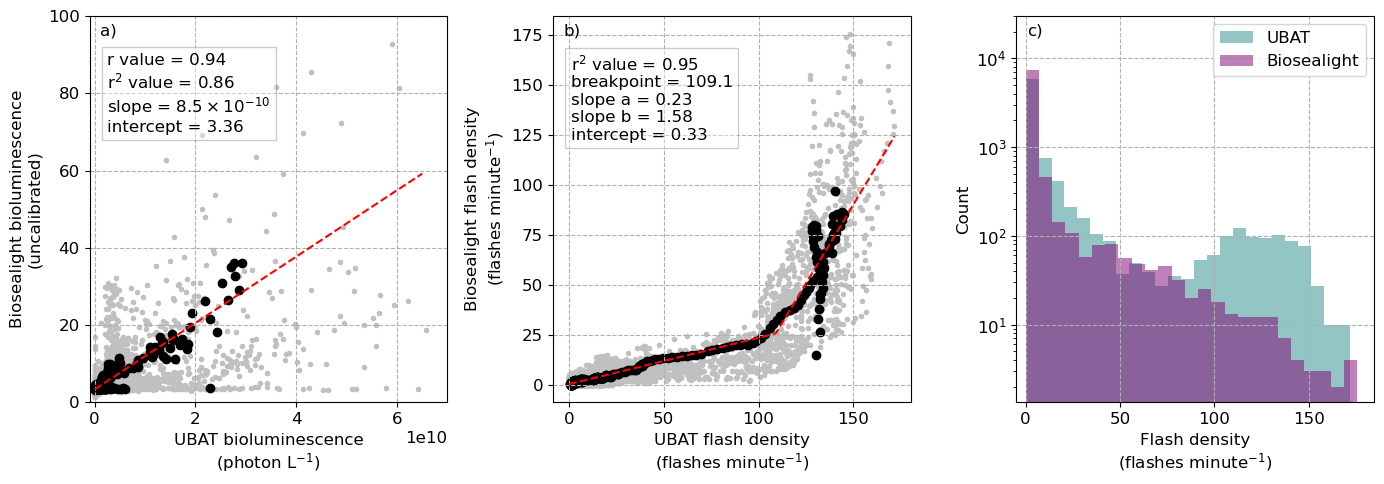

In [21]:
# plot the results

fig, ax = plt.subplots(1,3, figsize=(14,5))

################################################
# SMOOTH PROFILES

ax[0].scatter(smooth.ubat_smooth.values, smooth.cem_smooth.values, c='silver', marker='.')
ax[0].scatter(smooth.ubat_smooth.mean(axis=0).values, smooth.cem_smooth.mean(axis=0).values, c='k', marker='o')
fitx = np.linspace(np.nanmin(smooth.ubat_smooth),6.5e10,5)
ax[0].plot(fitx, fitx*res.slope+res.intercept, c='r', ls='--')
txt = ('r value = %0.2f\nr$^2$ value = %0.2f\nslope = $%s\\times10^{-10}$\nintercept = %0.2f' %(res.rvalue,r2,str(res.slope)[:3],res.intercept))
ax[0].text(0.05,0.7, txt, transform=ax[0].transAxes, bbox=dict(fc='white', ec='grey', alpha=0.4))
ax[0].text(0.03,0.95, 'a)', transform=ax[0].transAxes)

ax[0].set_xlabel('UBAT bioluminescence\n(photon L$^{-1}$)')
ax[0].set_ylabel('Biosealight bioluminescence\n(uncalibrated)')
ax[0].grid(ls='--')
ax[0].set_xlim(-0.1e10, 7e10)
ax[0].set_ylim(0, 100)

################################################
# FLASH DENSITY PROFILES
ax[1].scatter(FD.ubat.values, FD.cem.values, c='silver', marker='.')
ax[1].scatter(FD.ubat.mean(axis=0).values, FD.cem.mean(axis=0).values, c='k', marker='o')
ax[1].plot(fitx_2, fity_2, ls='--', c='r')
txt = ("r$^2$ value = %0.2f\nbreakpoint = %0.1f\nslope a = %0.2f\nslope b = %0.2f\nintercept = %0.2f" %(r2_2, x0, a, b+a, c))
ax[1].text(0.05,0.68, txt, transform=ax[1].transAxes, bbox=dict(fc='white', ec='grey', alpha=0.4))
ax[1].text(0.03,0.95, 'b)', transform=ax[1].transAxes)

ax[1].set_xlabel('UBAT flash density\n(flashes minute$^{-1}$)')
ax[1].set_ylabel('Biosealight flash density\n(flashes minute$^{-1}$)')
ax[1].grid(ls='--')

################################################
# HISTOGRAM OF FLASH DENSITY ESITMATES

ax[2].hist(FD.ubat.values.flatten(), 25, color=uc, alpha=0.5, label='UBAT')
ax[2].hist(FD.cem.values.flatten(), 25, color=cc, alpha=0.5, label='Biosealight')
ax[2].set_yscale('log')
ax[2].grid(ls='--')
ax[2].set_xlabel('Flash density\n(flashes minute$^{-1}$)')
ax[2].set_ylabel('Count')
ax[2].legend()
ax[2].set_ylim(None, 3e4)
ax[2].set_xlim(-5, None)
ax[2].text(0.03,0.95, 'c)', transform=ax[2].transAxes)


plt.tight_layout()
plt.show()

In [87]:
# check percentage of points below and above the breakpoint in the flash density model

x = FD.ubat.values.flatten()
y = FD.cem.values.flatten()
mask = ~np.isnan(x)&~np.isnan(y)
x = x[mask]
y = y[mask]
print('percentage of plots below breakpoint: %0.0f%%' % (100*(len(x[x<109.1])/len(x))))
print('percentage of plots above breakpoint: %0.0f%%' % (100*(len(x[x>=109.1])/len(x))))

print('check')
print('percentage of plots below breakpoint: %0.0f%%' % (100*(len(y[y<25.65])/len(x))))
print('percentage of plots above breakpoint: %0.0f%%' % (100*(len(y[y>=25.65])/len(x))))


percentage of plots below breakpoint: 93%
percentage of plots above breakpoint: 7%
check
percentage of plots below breakpoint: 93%
percentage of plots above breakpoint: 7%
